# Car Sales — Exploratory Data Analysis
**Team: LGTSOW**
**Notebook 1 — EDA**
**File:** `CarSales_Large.csv`

This notebook explores the large used-car listings dataset to understand its structure, distributions, data quality issues, and relationships with the target variable, `price`. The goal is to leave someone who has never seen this dataset with a clear picture of what it contains, what's broken, and what looks predictive — and to hand off a concrete list of preprocessing fixes to Notebook 2.

**Sections**
1. Structure (shape, dtypes, missingness, likely-useless columns, data errors)
2. Univariate distributions (numeric + categorical)
3. Bivariate relationships (correlation with price, multicollinearity)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'

DATA_PATH = '/scratch/user/u.gd352312/Car_Sales/CarSales_Large.csv'
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Rows: {df.shape[0]:,}    Columns: {df.shape[1]}")


Rows: 302,590    Columns: 66


## 1. Structure

### 1.1 Shape and dtypes

In [2]:
print(df.dtypes.to_string())

Unnamed: 0                   int64
city                        object
back_legroom                object
bed                         object
bed_height                  object
bed_length                  object
body_type                   object
cabin                       object
city_fuel_economy          float64
combine_fuel_economy       float64
daysonmarket                 int64
dealer_zip                   int64
description                 object
engine_cylinders            object
engine_displacement        float64
engine_type                 object
exterior_color              object
fleet                       object
frame_damaged               object
franchise_dealer              bool
franchise_make              object
front_legroom               object
fuel_tank_volume            object
fuel_type                   object
has_accidents               object
height                      object
highway_fuel_economy       float64
horsepower                 float64
interior_color      

The dataset has **302,590 rows and 66 columns**. Pandas' type inference is only partially useful here: several columns that are conceptually numeric — `back_legroom`, `front_legroom`, `fuel_tank_volume`, `height`, `length`, `wheelbase`, `width`, `bed_length`, `bed_height`, `maximum_seating`, `power`, `torque` — are stored as **strings with a unit suffix** (e.g. `"34.4 in"`, `"24.6 gal"`, `"383 hp @ 5,600 RPM"`). These need to be parsed into numeric columns before they're usable in any model or correlation analysis. Several boolean-looking columns (`fleet`, `frame_damaged`, `has_accidents`, `isCab`, `salvage`, `theft_title`, `is_cpo`, `is_oemcpo`) are stored as `object` rather than `bool` because they contain missing values alongside `True`/`False`.

### 1.2 Missing values per column

In [3]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_tbl = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(missing_tbl[missing_tbl['missing_count'] > 0].to_string())

                         missing_count  missing_pct
combine_fuel_economy            302590       100.00
is_certified                    302590       100.00
vehicle_damage_category         302590       100.00
bed                             300273        99.23
cabin                           297035        98.16
is_oemcpo                       291404        96.30
is_cpo                          286809        94.78
bed_height                      264711        87.48
bed_length                      264711        87.48
owner_count                     147889        48.87
theft_title                     139504        46.10
salvage                         139504        46.10
isCab                           139504        46.10
has_accidents                   139504        46.10
frame_damaged                   139504        46.10
fleet                           139504        46.10
franchise_make                   78449        25.93
torque                           50601        16.72
highway_fuel

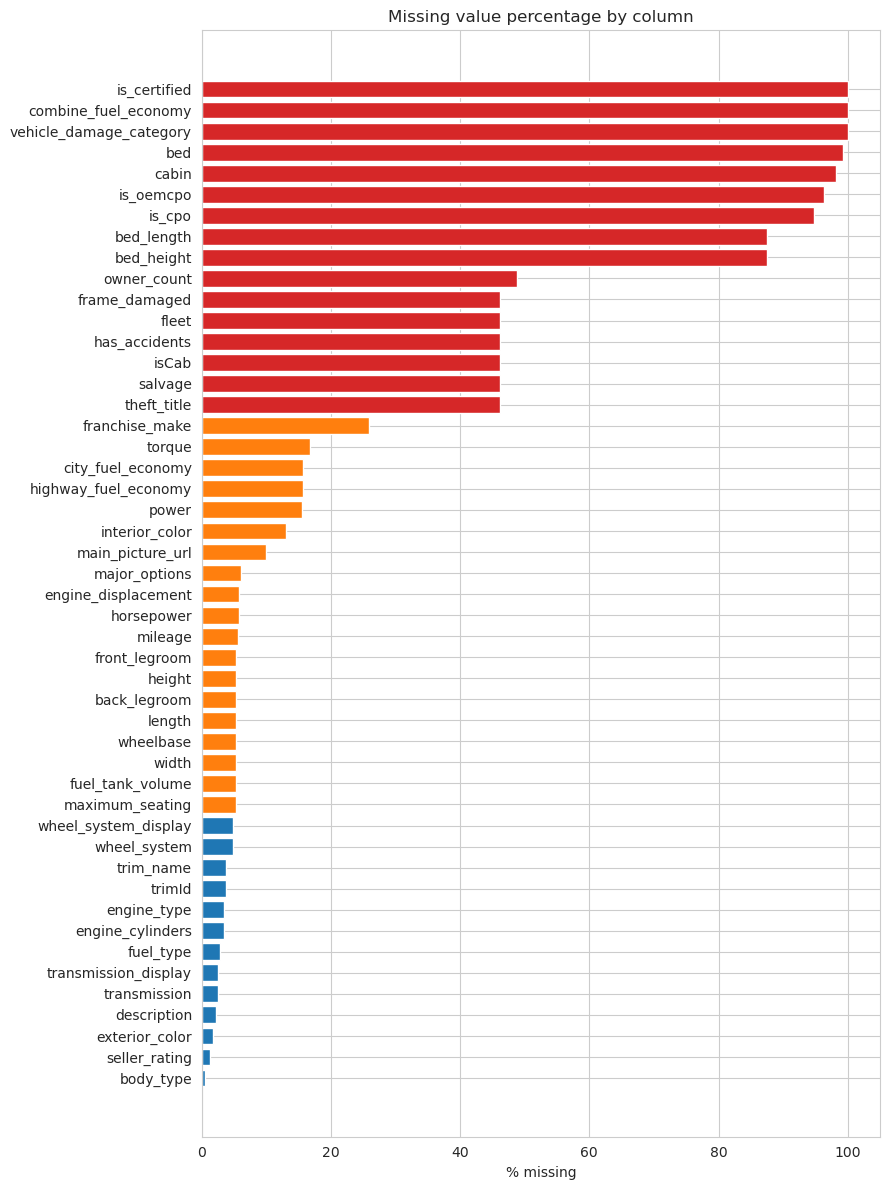

In [4]:
fig, ax = plt.subplots(figsize=(9, 12))
plot_data = missing_tbl[missing_tbl['missing_pct'] > 0].sort_values('missing_pct')
colors = ['#d62728' if v > 40 else ('#ff7f0e' if v > 5 else '#1f77b4') for v in plot_data['missing_pct']]
ax.barh(plot_data.index, plot_data['missing_pct'], color=colors)
ax.set_xlabel('% missing')
ax.set_title('Missing value percentage by column')
plt.tight_layout()
plt.show()

**Interpretation:** Missingness is not random — it clusters into a few meaningful groups:

- **Completely empty (100% missing) — drop entirely:** `is_certified`, `combine_fuel_economy`, `vehicle_damage_category`. These columns carry zero information.
- **Effectively empty:** `bed_height` (99.998% missing, and the tiny bit of non-null data is a literal `"--"` placeholder — see 1.3), `bed` (99.2%), `cabin` (98.2%), `is_oemcpo` (96.3%), `is_cpo` (94.8%), `bed_length` (87.5%). Most of the `bed*`/`cabin` missingness is **structural, not random** — these only apply to pickup trucks, so absence encodes "not a truck" rather than a data-collection failure.
- **Missing ~46% together** (`salvage`, `theft_title`, `frame_damaged`, `fleet`, `has_accidents`, `isCab`, `owner_count` at ~49%): these appear to be an optional "vehicle history" block that many listings simply didn't provide — likely correlated missingness from a single upstream data source (e.g., a CARFAX-style report) rather than independent random gaps.
- **Moderate missingness (5–25%):** `franchise_make`, `torque`, `power`, `city_fuel_economy`, `highway_fuel_economy`, `interior_color`, `major_options`, `engine_displacement`, `horsepower`, `mileage`, and the physical-dimension columns (`width`, `height`, `length`, `wheelbase`, `back_legroom`, `front_legroom`, `fuel_tank_volume`, `maximum_seating`) all sit around 5–16% missing, consistent with incomplete manufacturer-spec lookups for less common trims.
- **Low missingness (<5%):** the remaining columns, including `price` itself, which has **zero missing values** — good news, since it's the target.

### 1.3 Columns likely useless for predicting price

In [5]:
useless_notes = {
    'Unnamed: 0': 'Row index carried over from a prior export; duplicates listing_id information, no predictive content.',
    'is_certified': '100% missing.',
    'combine_fuel_economy': '100% missing.',
    'vehicle_damage_category': '100% missing.',
    'bed_height': 'Only non-null value is the literal placeholder string "--" (see 1.4) — carries no information.',
    'listing_id': 'Unique row identifier (302,587 unique values across 302,590 rows) — an ID, not a feature.',
    'main_picture_url': 'A URL string, effectively a near-unique identifier (254,865 unique values); no direct predictive signal.',
    'sp_id': 'Numeric dealer identifier; 3,275 unique values, essentially a categorical ID with no inherent ordering.',
    'sp_name': 'Dealer name string; 3,239 unique values, same identifier problem as sp_id.',
    'trimId': 'Internal trim code, 23,808 unique values — too high-cardinality to use directly, largely redundant with trim_name/model_name/year.',
    'description': 'Free-text dealer marketing copy; could feed an NLP pipeline later, but is not a usable numeric/categorical feature as-is.',
    'dealer_zip': '664 unique ZIP codes; too fine-grained to use directly as a category, though it could be binned into city/region (which city already provides).',
}
for col, note in useless_notes.items():
    print(f"- {col}: {note}")

- Unnamed: 0: Row index carried over from a prior export; duplicates listing_id information, no predictive content.
- is_certified: 100% missing.
- combine_fuel_economy: 100% missing.
- vehicle_damage_category: 100% missing.
- bed_height: Only non-null value is the literal placeholder string "--" (see 1.4) — carries no information.
- listing_id: Unique row identifier (302,587 unique values across 302,590 rows) — an ID, not a feature.
- main_picture_url: A URL string, effectively a near-unique identifier (254,865 unique values); no direct predictive signal.
- sp_id: Numeric dealer identifier; 3,275 unique values, essentially a categorical ID with no inherent ordering.
- sp_name: Dealer name string; 3,239 unique values, same identifier problem as sp_id.
- trimId: Internal trim code, 23,808 unique values — too high-cardinality to use directly, largely redundant with trim_name/model_name/year.
- description: Free-text dealer marketing copy; could feed an NLP pipeline later, but is not a us

**Interpretation:** Identifier-like columns (`Unnamed: 0`, `listing_id`, `main_picture_url`, `sp_id`, `sp_name`, `trimId`) should be dropped before modeling — they either carry no signal or would let a model "memorize" individual listings/dealers rather than learn generalizable relationships. The three 100%-missing columns and `bed_height` are dead weight and should be dropped outright. `dealer_zip` and `description` aren't necessarily useless, but they need feature engineering (geocoding/binning, or NLP/text features) before they're usable in a tabular price model — flagged for the preprocessing stage rather than dropped.

### 1.4 Clear data errors and quality issues

In [6]:
print("Duplicated listing_id values:", df['listing_id'].duplicated().sum())
print("Fully duplicated rows:", df.duplicated().sum())
print()
print("bed_height unique non-null values:", df['bed_height'].dropna().unique())
print()
print("Extreme mileage values (top 5):")
print(df['mileage'].sort_values(ascending=False).head(5).to_string())
print()
print("Rows with mileage > 1,000,000:")
print(df.loc[df['mileage'] > 1_000_000, ['make_name','model_name','year','mileage','price']].to_string())
print()
print("is_cpo unique values:", df['is_cpo'].unique())
print("is_oemcpo unique values:", df['is_oemcpo'].unique())
print()
print("horsepower vs power (parsed) mismatch count:")
power_hp_check = pd.to_numeric(df['power'].astype(str).str.extract(r'([\d,]+)\s*hp')[0].str.replace(',',''), errors='coerce')
mismatch = ((df['horsepower'] - power_hp_check).abs() > 0.01).sum()
print(f"{mismatch:,} rows out of {df['horsepower'].notna().sum():,} non-null horsepower rows differ from the hp parsed out of the 'power' text field")
print()
print("year range:", df['year'].min(), "-", df['year'].max())
print("Listings with year < 1980:", (df['year'] < 1980).sum())
print()
print("daysonmarket max:", df['daysonmarket'].max(), " (~", round(df['daysonmarket'].max()/365,1), "years)")

Duplicated listing_id values: 3
Fully duplicated rows: 0

bed_height unique non-null values: ['--']

Extreme mileage values (top 5):
55041     99999988.0
94537       590072.0
68962       397322.0
209754      392314.0
268274      391398.0

Rows with mileage > 1,000,000:
      make_name    model_name  year     mileage    price
55041       RAM  3500 Chassis  2019  99999988.0  52610.0

is_cpo unique values: [nan True]
is_oemcpo unique values: [nan True]

horsepower vs power (parsed) mismatch count:
24,791 rows out of 285,071 non-null horsepower rows differ from the hp parsed out of the 'power' text field

year range: 1923 - 2021
Listings with year < 1980: 277

daysonmarket max: 2416  (~ 6.6 years)


**Interpretation — data quality issues found (flagged for preprocessing):**

| # | Issue | Detail | Preprocessing action |
|---|---|---|---|
| 1 | Unit-suffixed numeric columns stored as text | `back_legroom`, `front_legroom`, `fuel_tank_volume`, `height`, `length`, `wheelbase`, `width`, `bed_length`, `bed_height`, `maximum_seating` all contain strings like `"34.4 in"` / `"24.6 gal"` / `"8 seats"` | Strip units with regex and cast to float before use |
| 2 | Composite text fields | `power` (`"383 hp @ 5,600 RPM"`) and `torque` (`"403 lb-ft @ 3,600 RPM"`) pack two numbers into one string | Split into separate numeric hp/RPM and lb-ft/RPM columns |
| 3 | Redundant/conflicting horsepower fields | `horsepower` and the hp value embedded in `power` disagree on **24,791 of 285,071** non-null rows | Pick one canonical source (or reconcile) rather than treating them as independent features |
| 4 | Placeholder value masquerading as data | `bed_height` is non-null for only 39 rows, and every one of those values is the literal string `"--"` | Drop the column (already flagged in 1.3) |
| 5 | Extreme/implausible mileage | One row (`RAM 3500 Chassis`, 2019, listed price \$52,610) has `mileage = 99,999,988` — almost certainly a sentinel/placeholder value, not a real odometer reading | Treat as missing or cap/clip during preprocessing |
| 6 | Pseudo-boolean columns encode "missing" as a third state | `is_cpo` and `is_oemcpo` only ever take the values `{True, NaN}` — `NaN` is standing in for `False` here, not "unknown" | Fill `NaN` → `False` and cast to real boolean |
| 7 | Boolean columns typed as `object` | `fleet`, `frame_damaged`, `has_accidents`, `isCab`, `salvage`, `theft_title` mix `True`/`False`/`NaN` as Python objects rather than a proper nullable boolean dtype | Cast to pandas nullable `boolean` dtype |
| 8 | Duplicate identifiers | 3 `listing_id` values are duplicated (though no fully duplicate rows) | Investigate and de-duplicate on `listing_id` |
| 9 | Very old vehicles mixed into a "used-car listings" dataset | Model years run from 1923 to 2021; a handful of pre-1980 vehicles (collector/antique cars) sit in a very different price regime than everyday used cars | Consider a floor on `year` or a separate "collector car" flag depending on modeling goal |
| 10 | Long-tail `daysonmarket` | Max value is 2,416 days (~6.6 years) on the market, versus a median of 34 days | Treat as a heavy-tailed feature; consider log-transform or capping |

Items 1–2 are the most consequential: **nine columns are currently unusable in any numeric model until parsed**, so this is the top priority for the preprocessing notebook.

## 2. Univariate Distributions

### 2.1 Numeric columns

First, let's clean up the unit-suffixed strings identified above so we can actually analyze them numerically. This mirrors the fix flagged in section 1.4 and will be carried into preprocessing.

In [7]:
def strip_unit(series):
    return pd.to_numeric(series.astype(str).str.extract(r'([\d\.]+)')[0], errors='coerce')

for col in ['back_legroom','front_legroom','fuel_tank_volume','height','length','wheelbase','width','bed_length']:
    df[col + '_num'] = strip_unit(df[col])

df['maximum_seating_num'] = pd.to_numeric(df['maximum_seating'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
df['power_hp'] = pd.to_numeric(df['power'].astype(str).str.extract(r'([\d,]+)\s*hp')[0].str.replace(',',''), errors='coerce')
df['torque_lbft'] = pd.to_numeric(df['torque'].astype(str).str.extract(r'([\d,]+)\s*lb-ft')[0].str.replace(',',''), errors='coerce')

print("Parsed new numeric columns:")
print([c for c in df.columns if c.endswith('_num') or c in ('power_hp','torque_lbft')])

Parsed new numeric columns:
['back_legroom_num', 'front_legroom_num', 'fuel_tank_volume_num', 'height_num', 'length_num', 'wheelbase_num', 'width_num', 'bed_length_num', 'maximum_seating_num', 'power_hp', 'torque_lbft']


In [8]:
numeric_cols = ['price','year','mileage','daysonmarket','horsepower','engine_displacement',
                'city_fuel_economy','highway_fuel_economy','seller_rating','owner_count','savings_amount',
                'back_legroom_num','front_legroom_num','fuel_tank_volume_num','height_num','length_num',
                'wheelbase_num','width_num','maximum_seating_num','power_hp','torque_lbft']
print(df[numeric_cols].describe().T.to_string())

                         count          mean            std     min           25%           50%           75%         max
price                 302590.0  29124.561564   20462.585945   386.9  17420.000000  25097.000000  37070.000000   1750000.0
year                  302590.0   2017.666073       4.155070  1923.0   2017.000000   2020.000000   2020.000000      2021.0
mileage               285616.0  33446.425228  192778.059076     0.0      7.000000  12410.000000  46393.250000  99999988.0
daysonmarket          302590.0     72.189874     105.813177     0.0     14.000000     34.000000     77.000000      2416.0
horsepower            285071.0    245.669886      90.979100    67.0    172.000000    241.000000    300.000000      1001.0
engine_displacement   285071.0   2932.350888    1322.870512   700.0   2000.000000   2500.000000   3600.000000      8400.0
city_fuel_economy     255261.0     22.892972       8.888540     8.0     18.000000     22.000000     26.000000       127.0
highway_fuel_economy  25

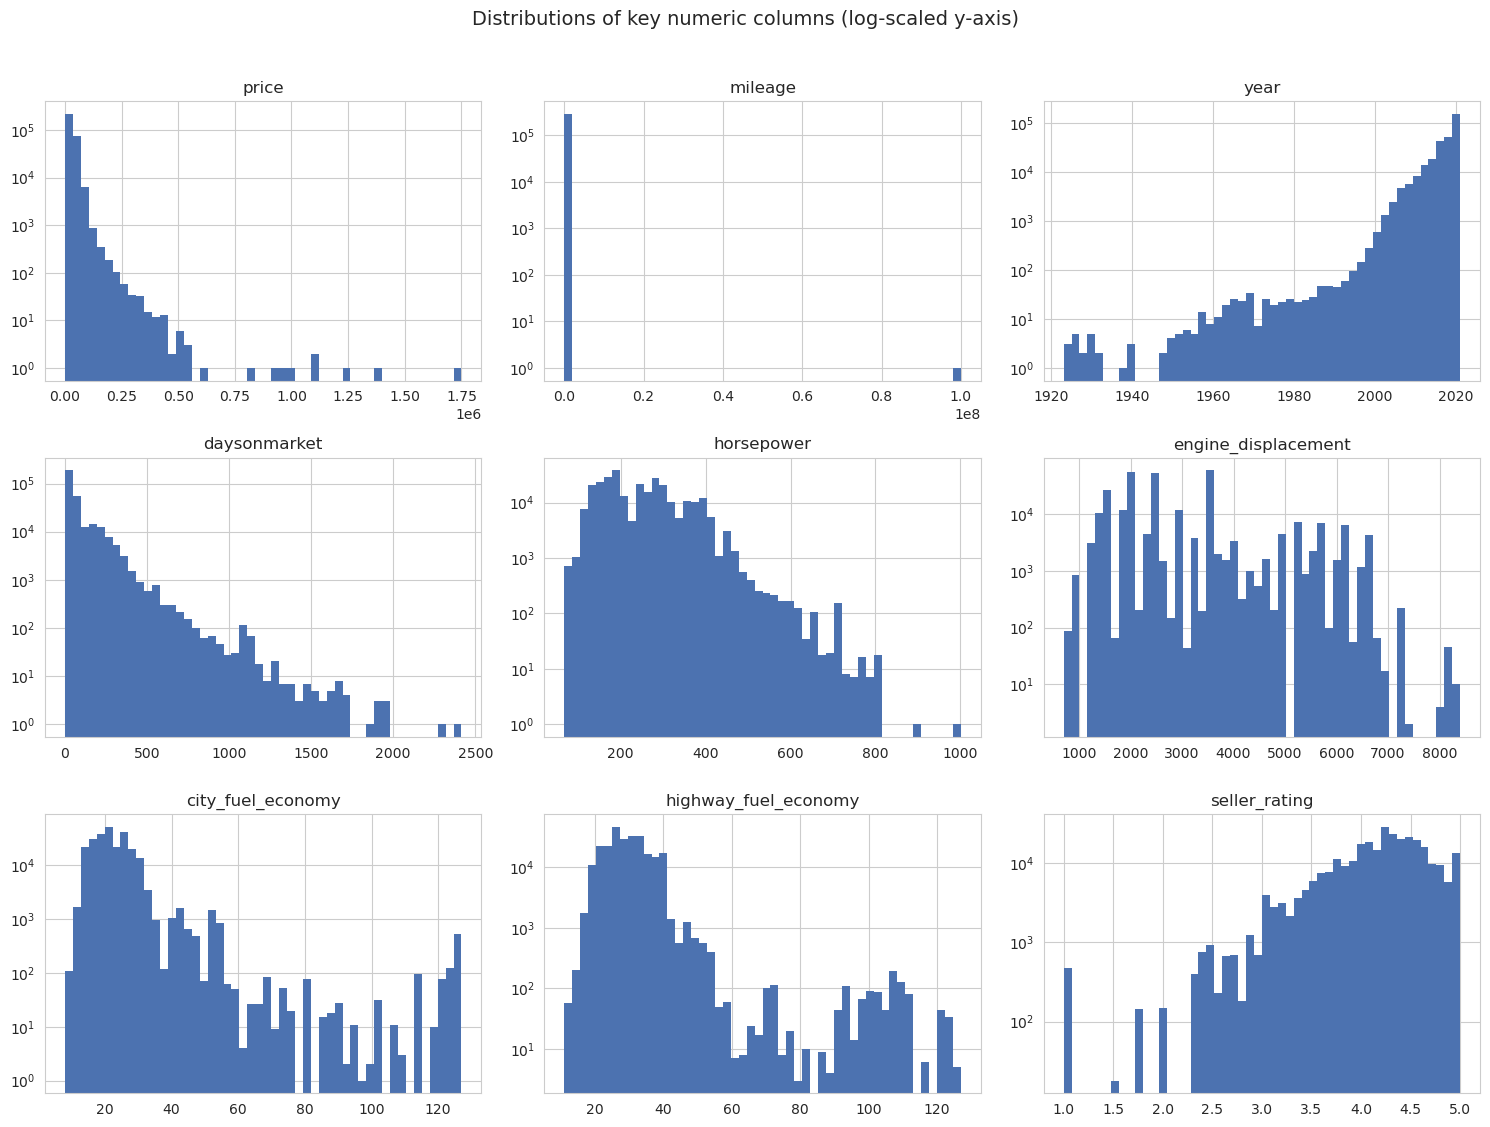

In [9]:
key_numeric = ['price','mileage','year','daysonmarket','horsepower','engine_displacement',
               'city_fuel_economy','highway_fuel_economy','seller_rating']
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flat, key_numeric):
    data = df[col].dropna()
    ax.hist(data, bins=50, color='#4C72B0', edgecolor='none')
    ax.set_title(col)
    ax.set_yscale('log')
fig.suptitle('Distributions of key numeric columns (log-scaled y-axis)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Interpretation:** Nearly every one of these distributions is **right-skewed**, which is typical for price/count data:

- **`price`** is unimodal but long-tailed — most listings cluster well under \$60K, with a thin tail stretching to \$1.75M (exotic/luxury vehicles).
- **`mileage`** is dominated by low-mileage/new vehicles near zero, with a long tail out to very high mileage (including the 99,999,988 sentinel error flagged earlier).
- **`daysonmarket`** decays sharply — most cars sell or get relisted within the first ~1–2 months, but a long tail sits on lots for years.
- **`year`** is left-skewed instead — the bulk of inventory is recent-model-year (2017–2021), with a thin trickle of much older collector vehicles.
- **`horsepower` and `engine_displacement`** are multi-modal, reflecting distinct clusters of economy 4-cylinders, mid-range V6s, and high-output V8s.
- **`seller_rating`** is left-skewed and tightly bounded (1–5 stars), with most dealers clustered around 4–4.5.

The skew in `price`, `mileage`, and `daysonmarket` is a strong signal that a log-transform (or similar) will likely help any model that assumes roughly linear/Gaussian relationships.

### Outlier detection (IQR method)

In [10]:
def iqr_outliers(s):
    s = s.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_lo, n_hi = (s < lo).sum(), (s > hi).sum()
    return pd.Series({'lower_bound': round(lo,1), 'upper_bound': round(hi,1),
                       'n_low_outliers': n_lo, 'n_high_outliers': n_hi,
                       'pct_outliers': round((n_lo+n_hi)/len(s)*100, 2)})

outlier_cols = ['price','mileage','daysonmarket','horsepower','engine_displacement','seller_rating']
outlier_tbl = pd.DataFrame({c: iqr_outliers(df[c]) for c in outlier_cols}).T
print(outlier_tbl.to_string())

                     lower_bound  upper_bound  n_low_outliers  n_high_outliers  pct_outliers
price                   -12055.0      66545.0             0.0          10023.0          3.31
mileage                 -69572.4     115972.6             0.0          22353.0          7.83
daysonmarket               -80.5        171.5             0.0          41769.0         13.80
horsepower                 -20.0        492.0             0.0           2001.0          0.70
engine_displacement       -400.0       6000.0             0.0          12160.0          4.27
seller_rating                3.1          5.4          9552.0              0.0          3.20


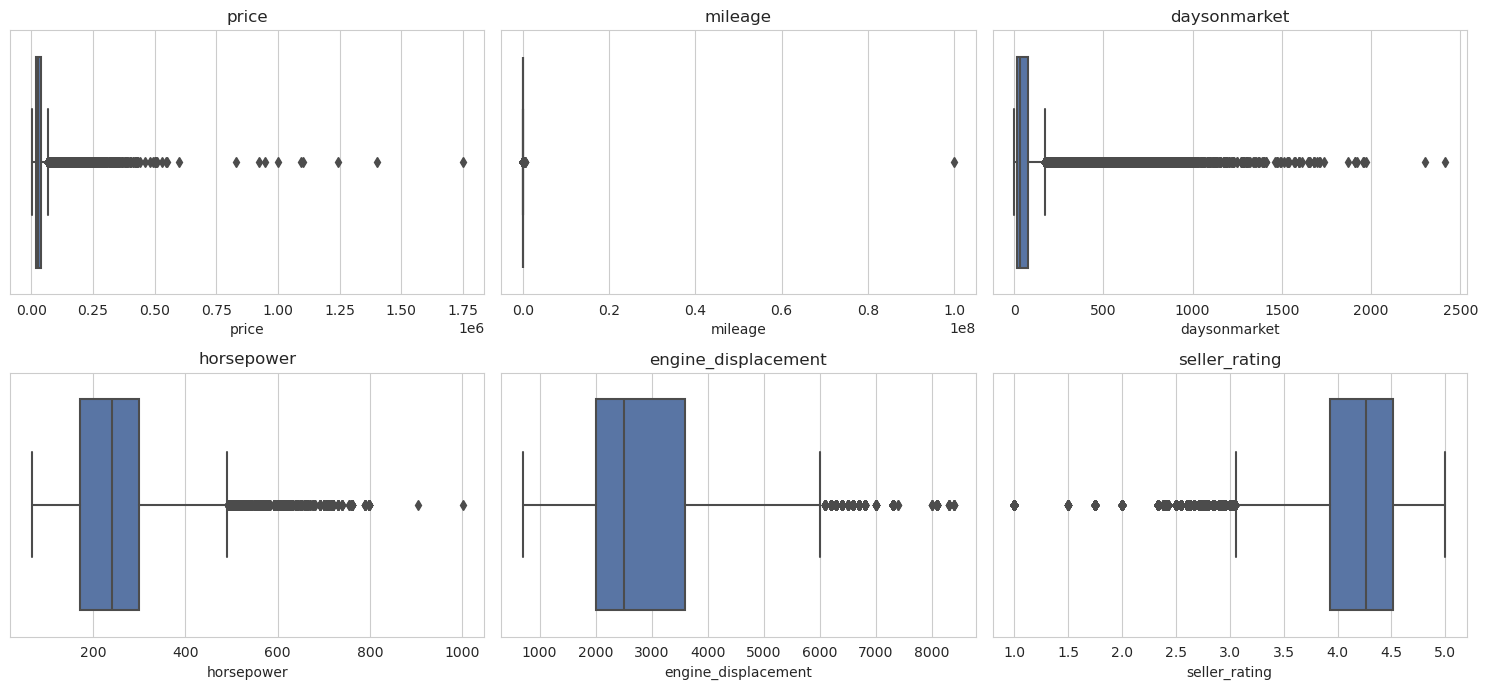

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flat, outlier_cols):
    sns.boxplot(x=df[col].dropna(), ax=ax, color='#4C72B0')
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Interpretation — which columns have significant outliers:**

- **`daysonmarket`** has the most outliers by far (~13.8% of rows above the IQR fence of ~172 days) — but these are plausible, real "stale listing" cars rather than data errors.
- **`mileage`** has ~7.8% high-side outliers, dominated by high-mileage older vehicles, plus the one clearly erroneous ~100M-mile sentinel value identified in section 1.4.
- **`engine_displacement`** (~4.3%) and **`price`** (~3.3%) have moderate outlier rates driven by legitimate large-engine trucks and luxury/exotic vehicles respectively — these are real market variation, not errors, but they will pull linear models around and may warrant robust scaling or a log-transform.
- **`seller_rating`** outliers are on the *low* side only (bounds ~3.1–5.4) — a small number of poorly-rated dealers.
- **`horsepower`** has the fewest outliers (0.7%), suggesting it's fairly well-behaved once cleaned.

None of these outlier rates look like they invalidate the columns — mostly they reflect genuine market heterogeneity (luxury cars, work trucks, stale inventory) — but they should be handled deliberately (capping, log-transform, or robust models) rather than ignored.

### 2.2 Categorical columns — cardinality

In [12]:
cat_cols = df.select_dtypes(include=['object','bool']).columns.tolist()
cat_cols += [c for c in df.columns if df[c].dtype.name == 'str']
cat_cols = sorted(set(cat_cols) | {'make_name','model_name','body_type','fuel_type','transmission',
                                    'wheel_system','listing_color','city','franchise_make','engine_cylinders',
                                    'exterior_color','interior_color','trim_name','sp_name','major_options',
                                    'description','dealer_zip','trimId'})
card = pd.DataFrame({'n_unique': {c: df[c].nunique() for c in cat_cols if c in df.columns}})
card['pct_unique'] = (card['n_unique'] / len(df) * 100).round(2)
card = card.sort_values('n_unique', ascending=False)
print(card.to_string())

                      n_unique  pct_unique
description             260806       86.19
main_picture_url        254865       84.23
major_options            50632       16.73
trimId                   23808        7.87
interior_color            9731        3.22
exterior_color            7604        2.51
trim_name                 5713        1.89
sp_name                   3239        1.07
power                     1631        0.54
torque                    1601        0.53
model_name                1054        0.35
listed_date               1039        0.34
length                     771        0.25
dealer_zip                 664        0.22
height                     444        0.15
wheelbase                  441        0.15
width                      271        0.09
back_legroom               203        0.07
fuel_tank_volume           171        0.06
front_legroom               92        0.03
bed_length                  79        0.03
make_name                   74        0.02
franchise_m

**Interpretation — high-cardinality features:** Ranked by number of unique values, the standouts are `description` (260,806 — essentially free text), `main_picture_url` (254,865), `major_options` (50,632 — a semi-structured list stored as one string), `trimId` (23,808), `mileage`-adjacent identifiers like `dealer_zip` (664), `sp_name`/`sp_id` (~3,240), `trim_name` (5,713), `interior_color` (9,731), and `exterior_color` (7,604). `model_name` (1,054) is moderately high but usable if grouped with `make_name`.

These need special handling before modeling: one-hot encoding `interior_color`/`exterior_color`/`trim_name` directly would explode the feature space; `major_options` should be parsed into individual boolean flags (it's a Python-list-formatted string of option names); `description` needs NLP treatment or should be dropped for a first pass; and identifier-like fields (`trimId`, `sp_id`, `sp_name`, `dealer_zip`) are better represented as grouped/aggregated features (e.g., dealer average price, ZIP-to-region mapping) than as raw categories.

By contrast, `make_name` (74), `body_type` (9), `fuel_type` (7), `transmission` (4), `wheel_system` (5), and `listing_color` (15) are low-cardinality and safe to one-hot or target-encode directly.

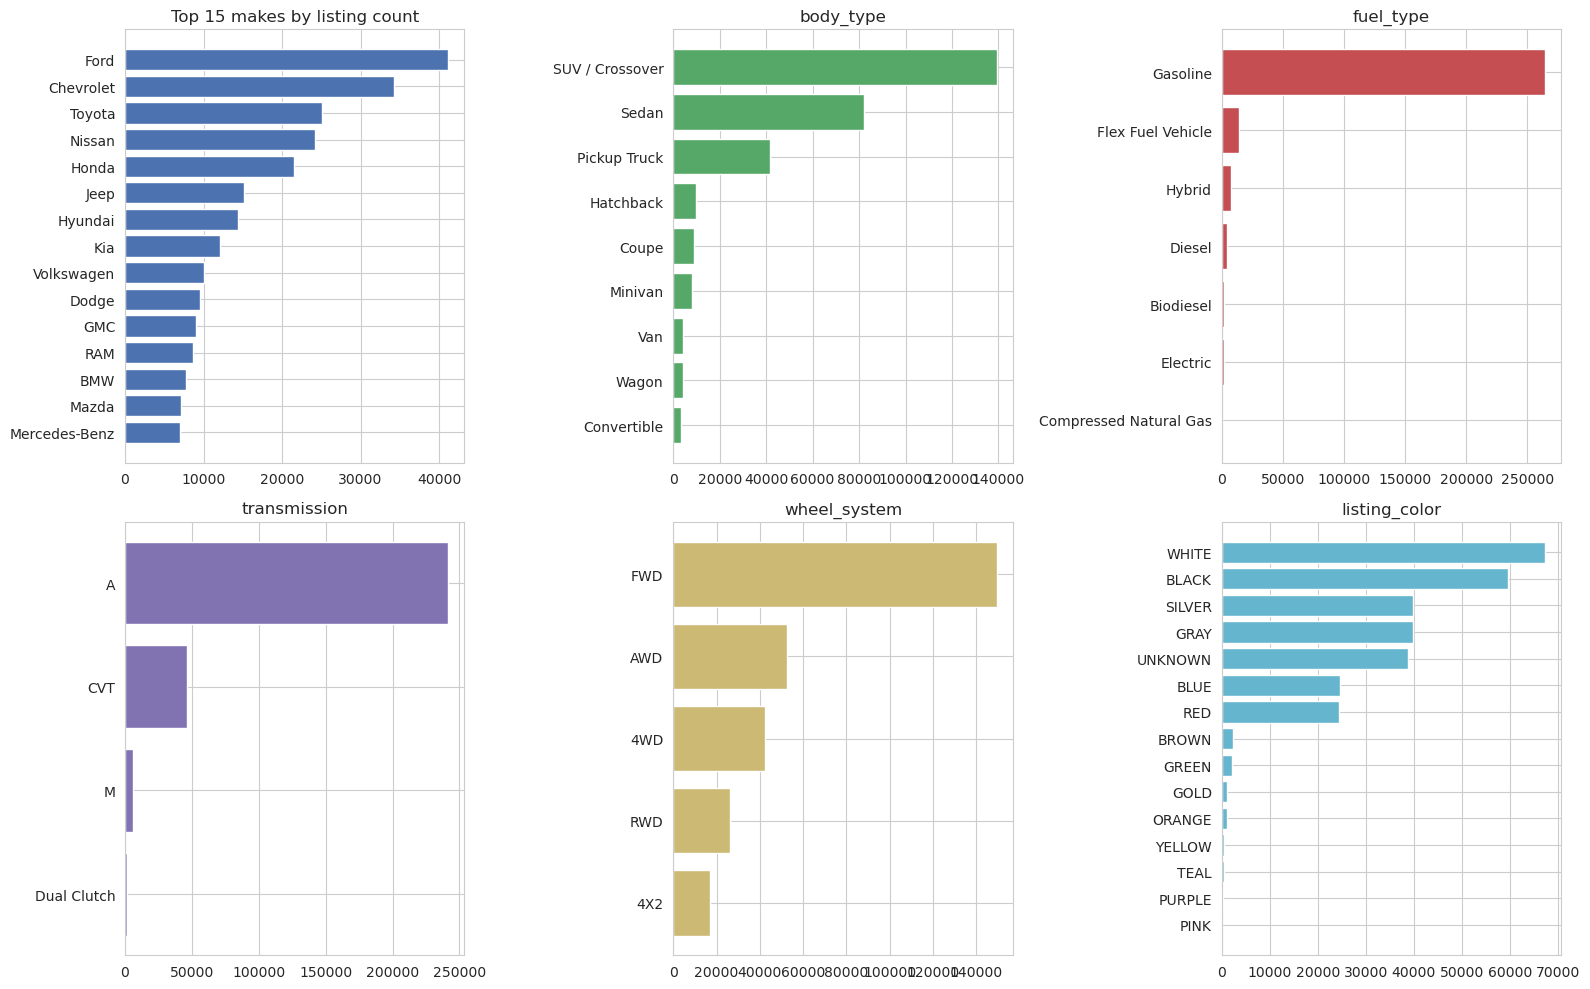

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

top_makes = df['make_name'].value_counts().head(15)
axes[0,0].barh(top_makes.index[::-1], top_makes.values[::-1], color='#4C72B0')
axes[0,0].set_title('Top 15 makes by listing count')

bt = df['body_type'].value_counts()
axes[0,1].barh(bt.index[::-1], bt.values[::-1], color='#55A868')
axes[0,1].set_title('body_type')

ft = df['fuel_type'].value_counts()
axes[0,2].barh(ft.index[::-1], ft.values[::-1], color='#C44E52')
axes[0,2].set_title('fuel_type')

tr = df['transmission'].value_counts()
axes[1,0].barh(tr.index[::-1], tr.values[::-1], color='#8172B2')
axes[1,0].set_title('transmission')

ws = df['wheel_system'].value_counts()
axes[1,1].barh(ws.index[::-1], ws.values[::-1], color='#CCB974')
axes[1,1].set_title('wheel_system')

lc = df['listing_color'].value_counts()
axes[1,2].barh(lc.index[::-1], lc.values[::-1], color='#64B5CD')
axes[1,2].set_title('listing_color')

plt.tight_layout()
plt.show()

**Interpretation:** Inventory is heavily concentrated: **Ford, Chevrolet, Toyota, Nissan, and Honda** together account for a large share of all listings, so a model needs enough examples of less-common makes (exotics like Ferrari/Bugatti/McLaren) to avoid just learning "expensive brand = high price" without nuance. `body_type` is dominated by **SUV/Crossover** (~46%) and **Sedan** (~27%), reflecting current US market composition. `fuel_type` is overwhelmingly **Gasoline** (~87%), with Electric/CNG vehicles rare enough that a model may struggle to learn their pricing patterns well without oversampling or a dedicated pricing rule. **Automatic transmission** and **FWD** dominate, and **White/Black/Silver/Gray** account for the large majority of listing colors — with a notable `UNKNOWN` bucket (~38.7K listings) worth flagging as another missingness-in-disguise issue.

## 3. Bivariate Relationships

### 3.1 What correlates with price?

In [14]:
corr_cols = ['price','year','mileage','daysonmarket','horsepower','city_fuel_economy','highway_fuel_economy',
             'engine_displacement','seller_rating','owner_count','savings_amount',
             'back_legroom_num','front_legroom_num','fuel_tank_volume_num','height_num','length_num',
             'wheelbase_num','width_num','maximum_seating_num','power_hp','torque_lbft']
corr_matrix = df[corr_cols].corr(numeric_only=True)
price_corr = corr_matrix['price'].drop('price').sort_values(ascending=False)
print(price_corr.to_string())

horsepower              0.605429
power_hp                0.573635
torque_lbft             0.529734
width_num               0.386183
fuel_tank_volume_num    0.379029
engine_displacement     0.362183
year                    0.358032
length_num              0.347332
wheelbase_num           0.345955
back_legroom_num        0.316900
height_num              0.278169
maximum_seating_num     0.111945
seller_rating           0.089174
front_legroom_num       0.067693
daysonmarket            0.050504
savings_amount          0.041009
mileage                -0.105582
city_fuel_economy      -0.169005
owner_count            -0.212874
highway_fuel_economy   -0.243255


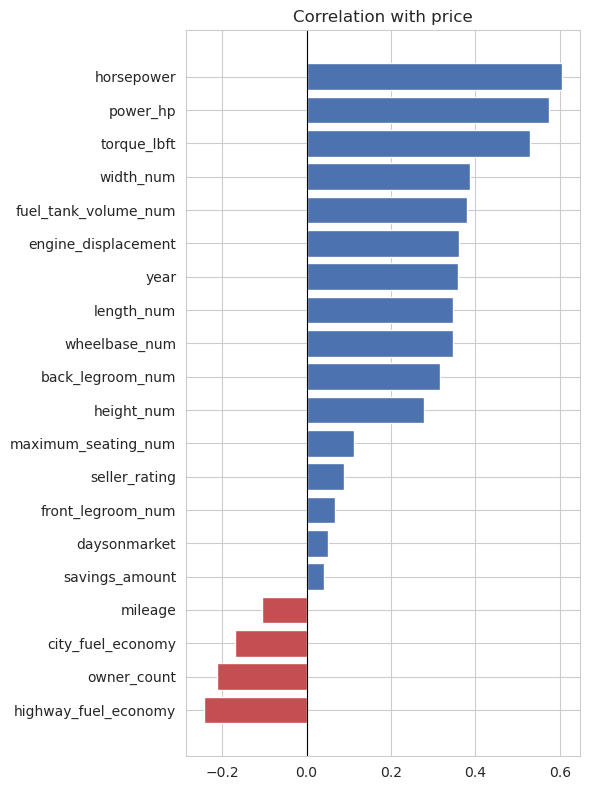

In [15]:
fig, ax = plt.subplots(figsize=(6, 8))
colors = ['#C44E52' if v < 0 else '#4C72B0' for v in price_corr.values]
ax.barh(price_corr.index[::-1], price_corr.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation with price')
plt.tight_layout()
plt.show()

**Interpretation:** The strongest positive correlates with `price` are all **power/size/performance** related: `horsepower` (r≈0.61) and its near-duplicate `power_hp` (r≈0.57), `torque_lbft` (r≈0.53), and vehicle size proxies like `width_num` (r≈0.39), `fuel_tank_volume_num` (r≈0.38), `engine_displacement` (r≈0.36), and `year` (r≈0.36, newer cars cost more). The strongest negative correlates are **fuel economy** (`highway_fuel_economy` r≈-0.24, `city_fuel_economy` r≈-0.17 — bigger/more powerful cars are less efficient, so this is really the mirror image of the positive correlations) and `owner_count` (r≈-0.21, more previous owners → lower price, consistent with age/wear). `mileage` shows a surprisingly modest negative correlation (r≈-0.11) on its own — likely because its relationship with price is confounded by `year` and vehicle segment (a high-mileage luxury SUV can still cost more than a low-mileage economy car), so it will matter more in combination with other features than in isolation. None of these correlations individually exceeds ~0.6, which tells us **no single feature dominates** — price prediction will need to combine several moderately-correlated features rather than rely on one strong predictor.

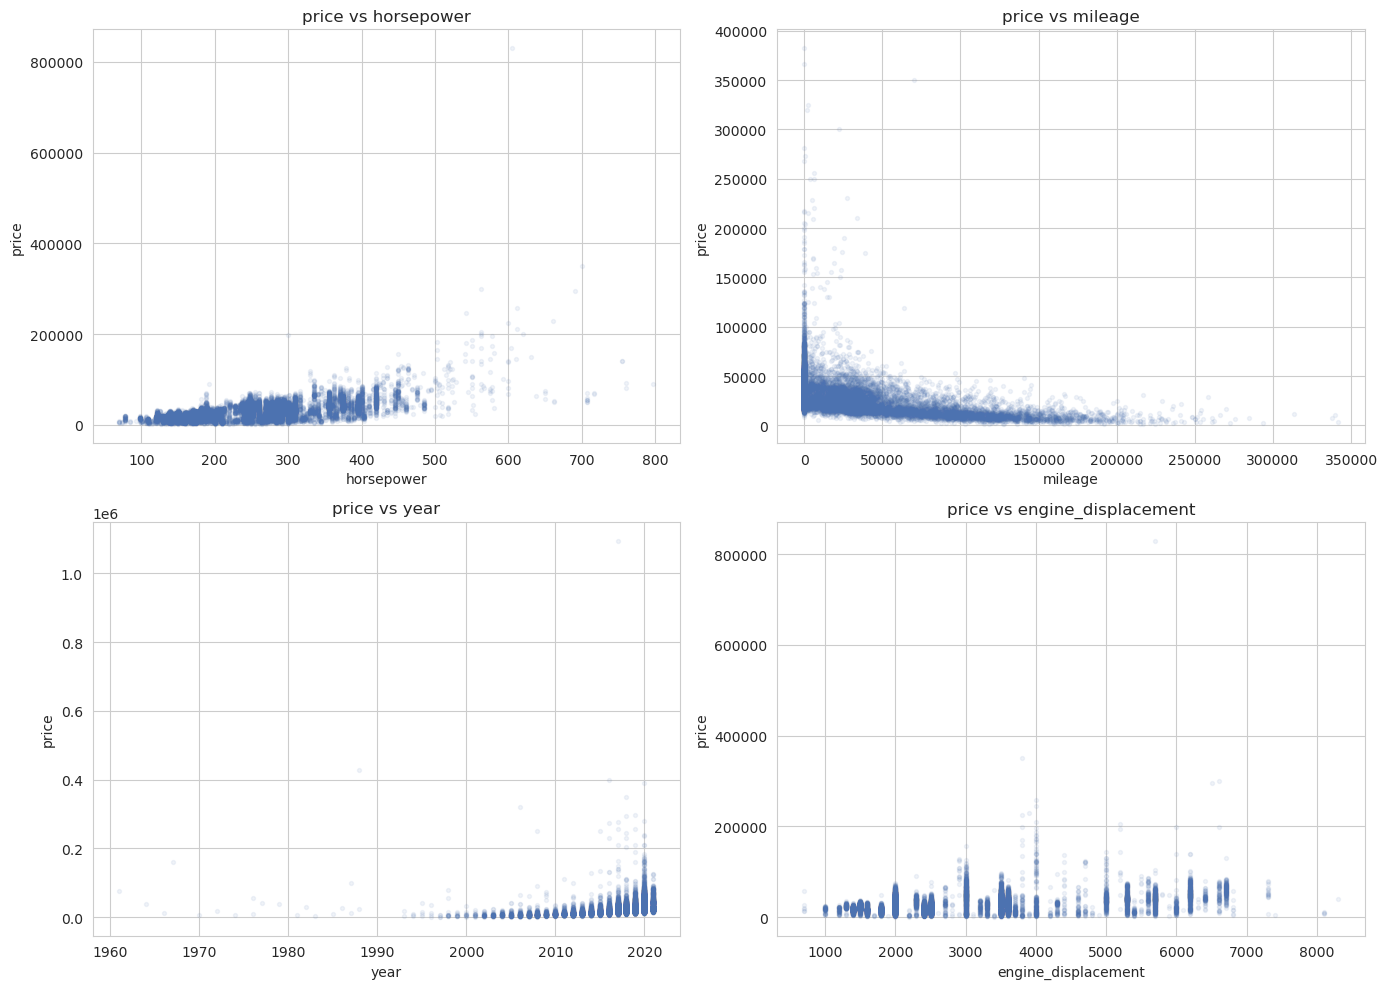

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
scatter_pairs = [('horsepower','price'), ('mileage','price'), ('year','price'), ('engine_displacement','price')]
for ax, (x, y) in zip(axes.flat, scatter_pairs):
    sample = df[[x, y]].dropna().sample(min(15000, df[[x,y]].dropna().shape[0]), random_state=42)
    ax.scatter(sample[x], sample[y], alpha=0.08, s=8, color='#4C72B0')
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{y} vs {x}')
plt.tight_layout()
plt.show()

**Interpretation:** The `horsepower` vs `price` scatter shows a clear (noisy) upward trend, consistent with its moderate correlation. `mileage` vs `price` shows the classic depreciation curve — a dense cloud of low-mileage/high-price and high-mileage/low-price points, but with substantial scatter (that confounding with year/segment mentioned above). `year` vs `price` shows the expected step-up for recent model years, plus a distinct, mostly-vertical band of very old (pre-1980) vehicles at unpredictable price levels — the "collector car" segment flagged earlier that likely needs separate handling. `engine_displacement` vs `price` shows a fan shape: small engines cluster tightly at lower prices, while larger-displacement engines show much wider price variance (economy V6s through luxury/exotic V8s).

### 3.2 Price by category

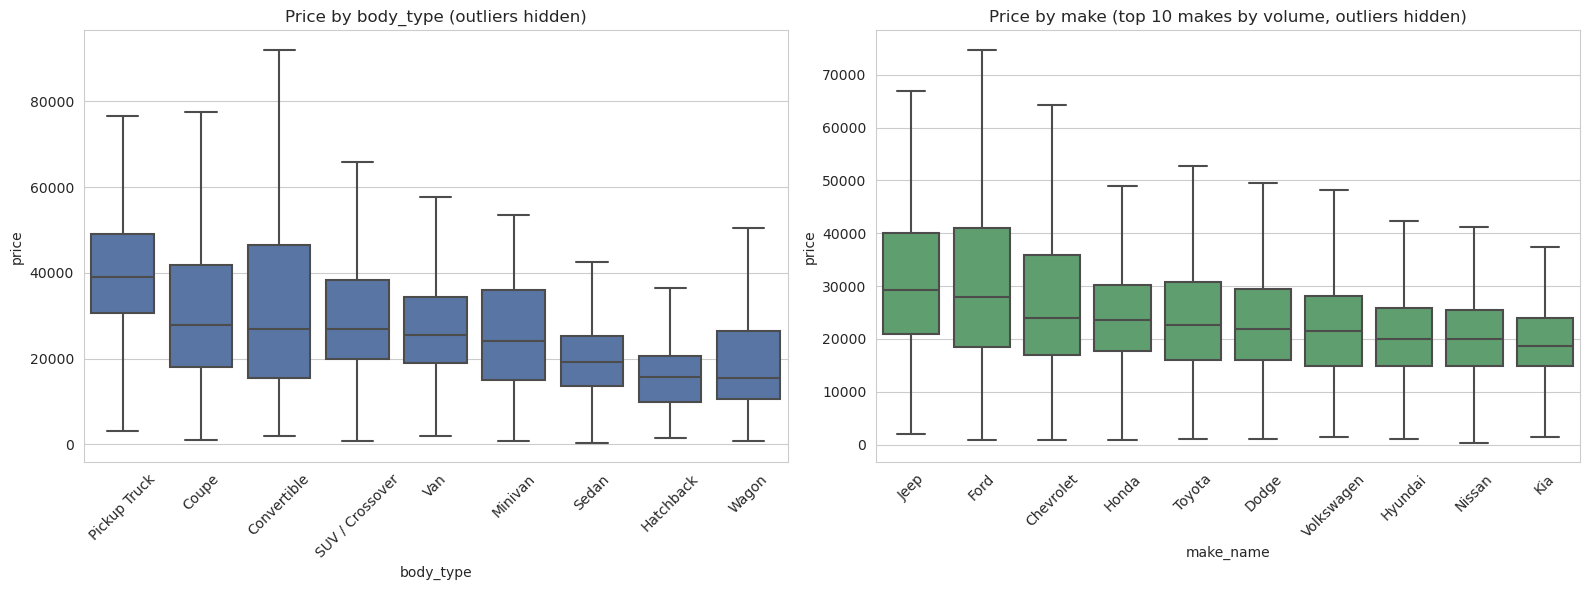

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order_bt = df.groupby('body_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='body_type', y='price', order=order_bt, ax=axes[0], showfliers=False, color='#4C72B0')
axes[0].set_title('Price by body_type (outliers hidden)')
axes[0].tick_params(axis='x', rotation=45)

top10_makes = df['make_name'].value_counts().head(10).index
order_mk = df[df['make_name'].isin(top10_makes)].groupby('make_name')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df[df['make_name'].isin(top10_makes)], x='make_name', y='price', order=order_mk,
            ax=axes[1], showfliers=False, color='#55A868')
axes[1].set_title('Price by make (top 10 makes by volume, outliers hidden)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Interpretation:** `body_type` shows a clear price hierarchy — **Convertibles and Pickup Trucks** command the highest median prices, while **Sedans and Hatchbacks** sit at the low end, confirming that vehicle segment carries real pricing information beyond what raw dimensions capture. Among the top 10 highest-volume makes, there's meaningful spread too (e.g., **Jeep and RAM/Ford trucks pricing higher than Nissan/Hyundai**), reinforcing that `make_name` and `body_type` are both useful categorical predictors, not redundant with the numeric spec columns.

### 3.3 Are price-correlated features correlated with each other? (multicollinearity check)

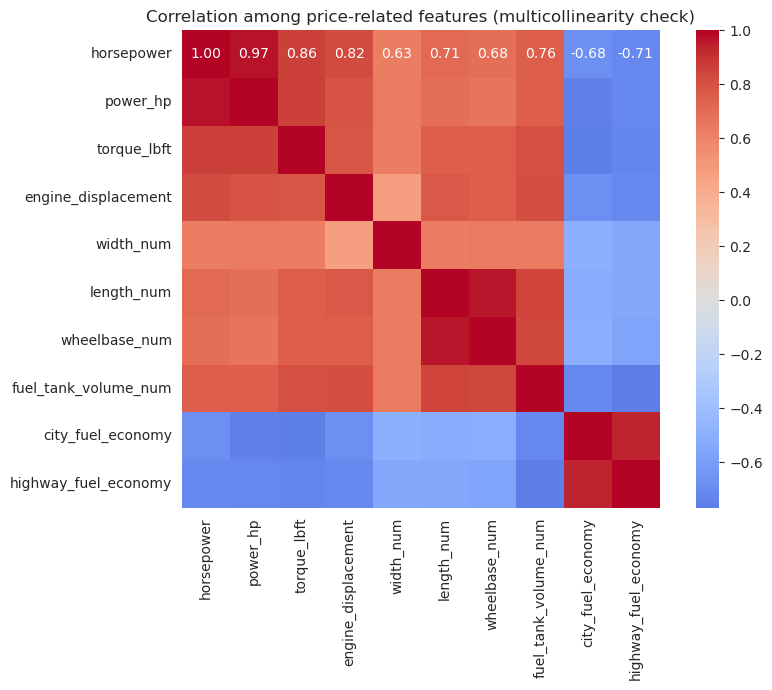

In [18]:
feature_corr_cols = ['horsepower','power_hp','torque_lbft','engine_displacement','width_num','length_num',
                      'wheelbase_num','fuel_tank_volume_num','city_fuel_economy','highway_fuel_economy']
feat_corr = df[feature_corr_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(feat_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlation among price-related features (multicollinearity check)')
plt.tight_layout()
plt.show()

**Interpretation:** Several of the features that correlate with `price` are also **strongly correlated with each other**, which is important context for modeling:

- **`horsepower` and `power_hp` (r≈0.97)** are near-duplicates (as already flagged in the data-quality section) — including both would add multicollinearity with no new information; keep one.
- **`city_fuel_economy` and `highway_fuel_economy` (r≈0.94)** move almost in lockstep — again, largely redundant; a single "fuel economy" feature (or their average) likely captures nearly all the signal.
- **`engine_displacement` correlates strongly with `horsepower` (r≈0.82)** and moderately with `fuel_tank_volume_num` (r≈0.76) — bigger engines come in bigger cars with bigger tanks, so these three are all partly measuring the same underlying "vehicle size/power class" concept.
- **`width_num`, `length_num`, and `wheelbase_num`** correlate moderately with each other (r≈0.6–0.7) and with `horsepower` — again, all proxies for overall vehicle size.
- **Fuel economy is strongly negatively correlated with size/power** (r≈-0.7 to -0.8 against horsepower, displacement, and fuel tank volume) — mechanically expected, and a reminder that fuel economy's negative correlation with price (section 3.1) is likely *mediated* by size/power rather than an independent effect.

**Practical takeaway for preprocessing/modeling:** this cluster of size/power/efficiency features is highly collinear. A tree-based model (random forest, gradient boosting) will handle this natively, but a linear model will need dimensionality reduction (PCA), regularization (Ridge/Lasso), or manual feature selection (e.g., keep `horsepower` and drop `power_hp`; keep `highway_fuel_economy` and drop `city_fuel_economy`) to avoid unstable coefficients.

## Summary of preprocessing flags for Notebook 2

1. Drop 100%-empty columns: `is_certified`, `combine_fuel_economy`, `vehicle_damage_category`, `bed_height`.
2. Drop identifier columns not useful as raw features: `Unnamed: 0`, `listing_id`, `main_picture_url`, `sp_id`, `sp_name`, `trimId`.
3. Parse unit-suffixed string columns to numeric: `back_legroom`, `front_legroom`, `fuel_tank_volume`, `height`, `length`, `wheelbase`, `width`, `bed_length`, `maximum_seating`.
4. Split composite text fields `power` and `torque` into separate numeric hp/torque and RPM columns.
5. Reconcile the conflicting `horsepower` vs. parsed-`power` values (24,791 disagreements) and pick one canonical source.
6. Clip/flag the erroneous ~100M-mile sentinel value in `mileage` (and consider a sanity cap more generally).
7. Recode `is_cpo`/`is_oemcpo` `NaN` → `False` and cast all True/False/NaN object columns to nullable boolean dtype.
8. Investigate and resolve the 3 duplicated `listing_id` rows.
9. Parse `major_options` (currently a stringified Python list) into individual boolean option flags.
10. Decide handling for the `UNKNOWN` bucket in `listing_color` (~38.7K rows) — treat as missing or as its own category.
11. Consider a log-transform for `price`, `mileage`, and `daysonmarket` given their strong right-skew.
12. Address multicollinearity among horsepower/power_hp, city/highway fuel economy, and engine size/dimension features before using linear models.
13. Decide how to treat pre-1980 "collector car" listings — separate flag or excluded from the main price model, since they follow a different pricing regime than everyday used cars.
14. Reduce high-cardinality categoricals (`exterior_color`, `interior_color`, `trim_name`) via grouping/target-encoding rather than naive one-hot encoding.